In [104]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import datetime
import csv

# Configuration
RESULTS_DIR = Path("../results")


In [105]:
# Define time range for concatenating measurements
start_str = "2026-01-05 23:59:02"  # inclusive start
end_str = "2026-01-06 09:00:00"  

type_meas = "full_swing" # full_swing

fourier_analysis = False
plot_data = True

interferometry_data_skipping_factor = 1


In [106]:
%matplotlib widget

In [107]:
start_dt = datetime.datetime.strptime(start_str, "%Y-%m-%d %H:%M:%S") + datetime.timedelta(seconds=5)
end_dt = datetime.datetime.strptime(end_str, "%Y-%m-%d %H:%M:%S") - datetime.timedelta(seconds=0)
if end_dt <= start_dt:
    raise ValueError("End datetime must be after start datetime")

# Find all files in the specified time range



In [108]:
def files_list(type_meas, exclude_set = None, start_dt = start_dt, end_dt = end_dt):
    files_in_range = []
    if exclude_set is None:
        exclude_set = []
    current_date = start_dt.date()
    while current_date <= end_dt.date():
        print(current_date)
        for file in sorted((RESULTS_DIR / current_date.strftime("%Y") / current_date.strftime("%m") / current_date.strftime("%d")).glob(f"{type_meas}_*.json")):
            # Skip if file is in exclusion list
            if file.name in exclude_set:
                print(f"  Excluding: {file.name}")
                continue
            
            # print(file.name)
            try:
                stamp = file.stem.split("_")[-1]  # expects v_meas_YYYYMMDD-HHMMSS.json
                dt = datetime.datetime.strptime(stamp, "%Y%m%d-%H%M%S")
                # print(dt)
            except ValueError:
                continue  # skip files that don't match the timestamp pattern
            if start_dt <= dt <= end_dt:
                print(dt)
                files_in_range.append((dt, file))
        current_date += datetime.timedelta(days=1)
    
    return files_in_range

In [109]:
exclude_set = ["full_swing_20260106-000022.json","full_swing_20260106-000310.json","full_swing_20260106-005157.json", 'full_swing_20260106-014647.json', 'full_swing_20260106-021808.json', 'full_swing_20260106-021841.json', 'full_swing_20260106-025901.json',"full_swing_20260106-030327.json"]
# exclude_set = []
files_in_range_full_swing = files_list("full_swing", exclude_set = exclude_set)
print(len(files_in_range_full_swing))

2026-01-05
2026-01-05 23:59:07
2026-01-05 23:59:10
2026-01-05 23:59:13
2026-01-05 23:59:16
2026-01-05 23:59:19
2026-01-05 23:59:22
2026-01-05 23:59:25
2026-01-05 23:59:28
2026-01-05 23:59:30
2026-01-05 23:59:33
2026-01-05 23:59:35
2026-01-05 23:59:38
2026-01-05 23:59:41
2026-01-05 23:59:43
2026-01-05 23:59:46
2026-01-05 23:59:49
2026-01-05 23:59:53
2026-01-05 23:59:56
2026-01-05 23:59:58
2026-01-06
2026-01-06 00:00:01
2026-01-06 00:00:04
2026-01-06 00:00:06
2026-01-06 00:00:09
2026-01-06 00:00:12
2026-01-06 00:00:14
2026-01-06 00:00:17
2026-01-06 00:00:20
  Excluding: full_swing_20260106-000022.json
2026-01-06 00:00:26
2026-01-06 00:00:29
2026-01-06 00:00:32
2026-01-06 00:00:34
2026-01-06 00:00:37
2026-01-06 00:00:40
2026-01-06 00:00:43
2026-01-06 00:00:45
2026-01-06 00:00:48
2026-01-06 00:00:51
2026-01-06 00:00:54
2026-01-06 00:00:56
2026-01-06 00:01:00
2026-01-06 00:01:03
2026-01-06 00:01:05
2026-01-06 00:01:08
2026-01-06 00:01:10
2026-01-06 00:01:13
2026-01-06 00:01:16
2026-01-06 00

In [110]:
exclude_set = ["v_meas_20260106-005342.json","v_meas_20260106-011322.json","v_meas_20260106-012006.json","v_meas_20260106-012147.json", 'v_meas_20260106-013430.json', 'v_meas_20260106-013718.json', 'v_meas_20260106-015008.json', 'v_meas_20260106-024138.json', 'v_meas_20260106-024607.json']
files_in_range_interferometry = files_list("v_meas", exclude_set = exclude_set)




2026-01-05
2026-01-05 23:59:09
2026-01-05 23:59:11
2026-01-05 23:59:14
2026-01-05 23:59:18
2026-01-05 23:59:21
2026-01-05 23:59:23
2026-01-05 23:59:26
2026-01-05 23:59:29
2026-01-05 23:59:32
2026-01-05 23:59:34
2026-01-05 23:59:37
2026-01-05 23:59:39
2026-01-05 23:59:42
2026-01-05 23:59:45
2026-01-05 23:59:48
2026-01-05 23:59:51
2026-01-05 23:59:54
2026-01-05 23:59:57
2026-01-06
2026-01-06 00:00:00
2026-01-06 00:00:02
2026-01-06 00:00:05
2026-01-06 00:00:08
2026-01-06 00:00:10
2026-01-06 00:00:13
2026-01-06 00:00:16
2026-01-06 00:00:19
2026-01-06 00:00:21
2026-01-06 00:00:28
2026-01-06 00:00:31
2026-01-06 00:00:33
2026-01-06 00:00:36
2026-01-06 00:00:39
2026-01-06 00:00:42
2026-01-06 00:00:44
2026-01-06 00:00:47
2026-01-06 00:00:50
2026-01-06 00:00:52
2026-01-06 00:00:55
2026-01-06 00:00:59
2026-01-06 00:01:01
2026-01-06 00:01:04
2026-01-06 00:01:07
2026-01-06 00:01:09
2026-01-06 00:01:12
2026-01-06 00:01:15
2026-01-06 00:01:17
2026-01-06 00:01:20
2026-01-06 00:01:23
2026-01-06 00:01:2

In [111]:
data_range = 4

# Option 1: Specify datetime strings (format: "YYYY-MM-DD HH:MM:SS")
# The code will find the closest matching file for each datetime string
data_datetime_strings = [
    "2026-01-06 01:01:27",  # First file of first set
    "2026-01-06 01:01:47",  # First file of second set
    "2026-01-06 01:15:23",  # First file of third set
    "2026-01-06 01:59:10",  # First file of fourth set
    "2026-01-06 02:41:00",  # First file of fourth set
    "2026-01-06 02:42:30",  # First file of fourth set
    "2026-01-06 02:48:00",  # First file of fourth set
    "2026-01-06 02:59:08",  # First file of fourth set
]

# Option 2: Specify indices directly (uncomment to use instead of datetime strings)
# data_index = [45, 100, 1500, 2000]  # Can specify multiple indices, e.g., [45, 50, 55]

# Initialize data_index (will be set below)
data_index = None

# Function to find index of closest datetime in file list
def find_datetime_index(target_dt_str, files_list):
    """Find the index of the file with datetime closest to target_dt_str"""
    target_dt = datetime.datetime.strptime(target_dt_str, "%Y-%m-%d %H:%M:%S")
    
    # Find the index with the minimum time difference
    min_diff = float('inf')
    best_idx = None
    
    for idx, (dt, file) in enumerate(files_list):
        diff = abs((dt - target_dt).total_seconds())
        if diff < min_diff:
            min_diff = diff
            best_idx = idx
    
    if best_idx is None:
        raise ValueError(f"Could not find file matching datetime: {target_dt_str}")
    
    return best_idx, min_diff

# Convert datetime strings to indices if provided
# Priority: if data_index is explicitly defined, use it; otherwise use data_datetime_strings
if 'data_index' in locals() and data_index is not None:
    # Use explicitly defined data_index
    print(f"Using provided indices: {data_index}")
elif 'data_datetime_strings' in locals() and data_datetime_strings:
    # Convert datetime strings to indices
    data_index = []
    for dt_str in data_datetime_strings:
        idx, diff = find_datetime_index(dt_str, files_in_range_interferometry)
        data_index.append(idx)
        print(f"Datetime {dt_str} -> Index {idx} (time difference: {diff:.1f} seconds)")
    print(f"\nConverted to indices: {data_index}")
else:
    raise ValueError("Either 'data_datetime_strings' or 'data_index' must be defined")

# Store file sets in 2D lists: one list per data_index entry
files_in_range_interferometry_sets = []
files_in_range_full_swing_sets = []

for idx in data_index:
    files_interferometry = files_in_range_interferometry[idx:idx + data_range]
    files_full_swing = files_in_range_full_swing[idx:idx + data_range]
    files_in_range_interferometry_sets.append(files_interferometry)
    files_in_range_full_swing_sets.append(files_full_swing)
    
    # Show the actual datetime of the first file for verification
    if files_interferometry:
        first_dt = files_interferometry[0][0]
        print(f"Index {idx}: {len(files_interferometry)} interferometry files, {len(files_full_swing)} full swing files (starts at {first_dt})")
    else:
        print(f"Index {idx}: No files found")

Datetime 2026-01-06 01:01:27 -> Index 1340 (time difference: 0.0 seconds)
Datetime 2026-01-06 01:01:47 -> Index 1347 (time difference: 0.0 seconds)
Datetime 2026-01-06 01:15:23 -> Index 1639 (time difference: 0.0 seconds)
Datetime 2026-01-06 01:59:10 -> Index 2580 (time difference: 0.0 seconds)
Datetime 2026-01-06 02:41:00 -> Index 3482 (time difference: 0.0 seconds)
Datetime 2026-01-06 02:42:30 -> Index 3513 (time difference: 0.0 seconds)
Datetime 2026-01-06 02:48:00 -> Index 3631 (time difference: 0.0 seconds)
Datetime 2026-01-06 02:59:08 -> Index 3870 (time difference: 0.0 seconds)

Converted to indices: [1340, 1347, 1639, 2580, 3482, 3513, 3631, 3870]
Index 1340: 4 interferometry files, 4 full swing files (starts at 2026-01-06 01:01:27)
Index 1347: 4 interferometry files, 4 full swing files (starts at 2026-01-06 01:01:47)
Index 1639: 4 interferometry files, 4 full swing files (starts at 2026-01-06 01:15:23)
Index 2580: 4 interferometry files, 4 full swing files (starts at 2026-01-0

In [112]:
# Process each set of files and store results
concat_time_full_swing_all = []
concat_voltage_min_full_swing_all = []
concat_voltage_max_full_swing_all = []
concat_voltage_avg_full_swing_all = []
base_dt_full_swing_all = []

for set_idx, files_in_range_full_swing in enumerate(files_in_range_full_swing_sets):
    if not files_in_range_full_swing:
        print(f"Set {set_idx} (index {data_index[set_idx]}): No files found in the specified range.")
        continue
    
    # Load and concatenate data from all files
    concat_time_full_swing = []
    concat_voltage_min_full_swing = []
    concat_voltage_max_full_swing = []
    concat_voltage_avg_full_swing = []
    concat_voltage_polarization_max_full_swing = []
    concat_voltage_polarization_min_full_swing = []
    base_dt = files_in_range_full_swing[0][0]  # anchor absolute time to the first capture

    for dt, file in files_in_range_full_swing:
        with open(file, "r") as f:
            d = json.load(f)
        t = np.array(d["time_s"], dtype=float)
        v = np.array(d["voltage_data_v"], dtype=float)
        if len(t) == 0 or len(v) == 0:
            continue

        # Offset this capture so its start reflects the true wall-clock interval
        offset = (dt - base_dt).total_seconds()
        concat_time_full_swing.append([(t + offset)[0]])
        concat_voltage_min_full_swing.append([np.min(v)])
        concat_voltage_max_full_swing.append([np.max(v)])
        concat_voltage_avg_full_swing.append([np.mean(v)])
        concat_voltage_polarization_max_full_swing.append([(np.max(v) - np.mean(v))/np.mean(v)])
        concat_voltage_polarization_min_full_swing.append([((np.min(v) - np.mean(v))/np.mean(v))])

    if not concat_time_full_swing:
        print(f"Set {set_idx} (index {data_index[set_idx]}): All files in range were empty after parsing.")
    else:
        concat_time_full_swing = np.concatenate(concat_time_full_swing)
        concat_voltage_min_full_swing = np.concatenate(concat_voltage_min_full_swing)
        concat_voltage_max_full_swing = np.concatenate(concat_voltage_max_full_swing)
        concat_voltage_avg_full_swing = np.concatenate(concat_voltage_avg_full_swing)
        
        # Store results for this set
        concat_time_full_swing_all.append(concat_time_full_swing)
        concat_voltage_min_full_swing_all.append(concat_voltage_min_full_swing)
        concat_voltage_max_full_swing_all.append(concat_voltage_max_full_swing)
        concat_voltage_avg_full_swing_all.append(concat_voltage_avg_full_swing)
        base_dt_full_swing_all.append(base_dt)
        
        print(f"Set {set_idx} (index {data_index[set_idx]}): Loaded {len(files_in_range_full_swing)} files")
        print(f"  Total data points: {len(concat_voltage_min_full_swing)}")
        print(f"  Time range: {base_dt} to {base_dt + datetime.timedelta(seconds=concat_time_full_swing[-1])}")

Set 0 (index 1340): Loaded 4 files
  Total data points: 4
  Time range: 2026-01-06 01:01:26 to 2026-01-06 01:01:35
Set 1 (index 1347): Loaded 4 files
  Total data points: 4
  Time range: 2026-01-06 01:01:46 to 2026-01-06 01:01:54
Set 2 (index 1639): Loaded 4 files
  Total data points: 4
  Time range: 2026-01-06 01:15:21 to 2026-01-06 01:15:30
Set 3 (index 2580): Loaded 4 files
  Total data points: 4
  Time range: 2026-01-06 01:59:08 to 2026-01-06 01:59:17
Set 4 (index 3482): Loaded 4 files
  Total data points: 4
  Time range: 2026-01-06 02:40:59 to 2026-01-06 02:41:08
Set 5 (index 3513): Loaded 4 files
  Total data points: 4
  Time range: 2026-01-06 02:42:28 to 2026-01-06 02:42:36
Set 6 (index 3631): Loaded 4 files
  Total data points: 4
  Time range: 2026-01-06 02:47:59 to 2026-01-06 02:48:07
Set 7 (index 3870): Loaded 4 files
  Total data points: 4
  Time range: 2026-01-06 02:59:07 to 2026-01-06 02:59:14


In [113]:
# Process interferometry data for each set
concat_time_interferometry_all = []
concat_voltage_interferometry_all = []
base_dt_interferometry_all = []

for set_idx, files_in_range_interferometry in enumerate(files_in_range_interferometry_sets):
    files_in_range_full_swing = files_in_range_full_swing_sets[set_idx]
    
    if not files_in_range_interferometry:
        print(f"Set {set_idx} (index {data_index[set_idx]}): No interferometry files found in the specified range.")
        continue

    elif len(files_in_range_interferometry) != len(files_in_range_full_swing):
        print(f"Set {set_idx} (index {data_index[set_idx]}): Number of files in range are not the same")
        print(f"  Full swing: {len(files_in_range_full_swing)}")
        print(f"  Interferometry: {len(files_in_range_interferometry)}")
        Warning("Number of files in range are not the same")
        continue
        
    else:
        # Load and concatenate data from all files
        concat_time_interferometry = []
        concat_voltage_interferometry = []
        base_dt = files_in_range_interferometry[0][0]  # anchor absolute time to the first capture

        for dt, file in files_in_range_interferometry:
            with open(file, "r") as f:
                d = json.load(f)
            t = np.array(d["time_s"], dtype=float)[::interferometry_data_skipping_factor]
            v = np.array(d["voltage_data_v"], dtype=float)[::interferometry_data_skipping_factor]
            if len(t) == 0 or len(v) == 0:
                continue

            # Offset this capture so its start reflects the true wall-clock interval
            offset = (dt - base_dt).total_seconds()
            concat_time_interferometry.append(t + offset)
            concat_voltage_interferometry.append(v)

        if not concat_time_interferometry:
            print(f"Set {set_idx} (index {data_index[set_idx]}): All files in range were empty after parsing.")
        else:
            concat_time_interferometry = np.concatenate(concat_time_interferometry)
            concat_voltage_interferometry = np.concatenate(concat_voltage_interferometry)
            
            # Store results for this set
            concat_time_interferometry_all.append(concat_time_interferometry)
            concat_voltage_interferometry_all.append(concat_voltage_interferometry)
            base_dt_interferometry_all.append(base_dt)
            
            print(f"Set {set_idx} (index {data_index[set_idx]}): Loaded {len(files_in_range_interferometry)} files")
            print(f"  Total data points: {len(concat_voltage_interferometry)}")
            print(f"  Time range: {base_dt} to {base_dt + datetime.timedelta(seconds=concat_time_interferometry[-1])}")

Set 0 (index 1340): Loaded 4 files
  Total data points: 20004
  Time range: 2026-01-06 01:01:27 to 2026-01-06 01:01:36.050000
Set 1 (index 1347): Loaded 4 files
  Total data points: 20004
  Time range: 2026-01-06 01:01:47 to 2026-01-06 01:01:55.050000
Set 2 (index 1639): Loaded 4 files
  Total data points: 20004
  Time range: 2026-01-06 01:15:23 to 2026-01-06 01:15:31.050000
Set 3 (index 2580): Loaded 4 files
  Total data points: 20004
  Time range: 2026-01-06 01:59:10 to 2026-01-06 01:59:18.050000
Set 4 (index 3482): Loaded 4 files
  Total data points: 20004
  Time range: 2026-01-06 02:41:00 to 2026-01-06 02:41:10.050000
Set 5 (index 3513): Loaded 4 files
  Total data points: 20004
  Time range: 2026-01-06 02:42:30 to 2026-01-06 02:42:38.050000
Set 6 (index 3631): Loaded 4 files
  Total data points: 20004
  Time range: 2026-01-06 02:48:00 to 2026-01-06 02:48:08.050000
Set 7 (index 3870): Loaded 4 files
  Total data points: 20004
  Time range: 2026-01-06 02:59:08 to 2026-01-06 02:59:16

In [114]:
def extending_data(data,factor,symmetric=True):
    if symmetric:
        return np.concatenate([np.repeat([data[0]],np.floor(factor/2)), np.repeat(data[1:],factor), np.repeat([data[-1]],np.ceil(factor/2))])
    else:
        return np.repeat(data, factor)
    
    

In [115]:
# Calculate cosine phase for each set
cosine_phase_all = []
extended_voltage_avg_full_swing_all = []
extended_voltage_max_full_swing_all = []
extended_voltage_min_full_swing_all = []

for set_idx in range(len(concat_time_interferometry_all)):
    concat_time_interferometry = concat_time_interferometry_all[set_idx]
    concat_voltage_interferometry = concat_voltage_interferometry_all[set_idx]
    concat_time_full_swing = concat_time_full_swing_all[set_idx]
    concat_voltage_avg_full_swing = concat_voltage_avg_full_swing_all[set_idx]
    concat_voltage_max_full_swing = concat_voltage_max_full_swing_all[set_idx]
    concat_voltage_min_full_swing = concat_voltage_min_full_swing_all[set_idx]
    
    if not(len(concat_time_interferometry)/len(concat_time_full_swing)).is_integer():
        print(f"Set {set_idx} (index {data_index[set_idx]}): Number of points in interferometry is not a multiple of full swing")
        continue
        
    factor = int(len(concat_time_interferometry)/len(concat_time_full_swing))
    print(f"Set {set_idx} (index {data_index[set_idx]}): Factor: {factor}")
    extended_voltage_avg_full_swing = extending_data(concat_voltage_avg_full_swing, factor, symmetric=False)
    extended_voltage_max_full_swing = extending_data(concat_voltage_max_full_swing, factor, symmetric=False)
    extended_voltage_min_full_swing = extending_data(concat_voltage_min_full_swing, factor, symmetric=False)
    cosine_phase = (concat_voltage_interferometry - extended_voltage_avg_full_swing)/(extended_voltage_max_full_swing - extended_voltage_avg_full_swing)
    
    # Store results for this set
    cosine_phase_all.append(cosine_phase)
    extended_voltage_avg_full_swing_all.append(extended_voltage_avg_full_swing)
    extended_voltage_max_full_swing_all.append(extended_voltage_max_full_swing)
    extended_voltage_min_full_swing_all.append(extended_voltage_min_full_swing)

Set 0 (index 1340): Factor: 5001
Set 1 (index 1347): Factor: 5001
Set 2 (index 1639): Factor: 5001
Set 3 (index 2580): Factor: 5001
Set 4 (index 3482): Factor: 5001
Set 5 (index 3513): Factor: 5001
Set 6 (index 3631): Factor: 5001
Set 7 (index 3870): Factor: 5001


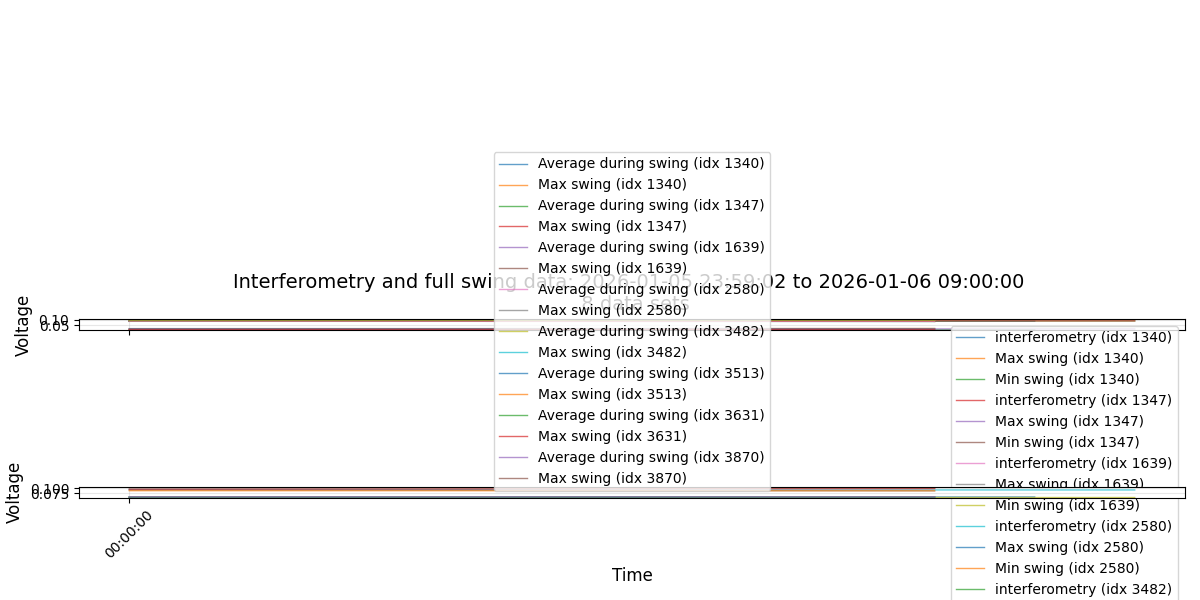


Files included (chronological) for each set:

Set 0 (index 1340):
  2026-01-06 01:01:27 -> v_meas_20260106-010127.json
  2026-01-06 01:01:30 -> v_meas_20260106-010130.json
  2026-01-06 01:01:34 -> v_meas_20260106-010134.json
  2026-01-06 01:01:36 -> v_meas_20260106-010136.json

Set 1 (index 1347):
  2026-01-06 01:01:47 -> v_meas_20260106-010147.json
  2026-01-06 01:01:50 -> v_meas_20260106-010150.json
  2026-01-06 01:01:53 -> v_meas_20260106-010153.json
  2026-01-06 01:01:55 -> v_meas_20260106-010155.json

Set 2 (index 1639):
  2026-01-06 01:15:23 -> v_meas_20260106-011523.json
  2026-01-06 01:15:26 -> v_meas_20260106-011526.json
  2026-01-06 01:15:28 -> v_meas_20260106-011528.json
  2026-01-06 01:15:31 -> v_meas_20260106-011531.json

Set 3 (index 2580):
  2026-01-06 01:59:10 -> v_meas_20260106-015910.json
  2026-01-06 01:59:13 -> v_meas_20260106-015913.json
  2026-01-06 01:59:15 -> v_meas_20260106-015915.json
  2026-01-06 01:59:18 -> v_meas_20260106-015918.json

Set 4 (index 3482):
 

In [116]:
# Plot the concatenated data for all sets
if len(cosine_phase_all) > 0:
    from datetime import timedelta
    import matplotlib.dates as mdates

    base_dt_plot = datetime.datetime.strptime("00:00:00", "%H:%M:%S")

    if plot_data:
        fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
        
        # Plot data for each set
        for set_idx in range(len(cosine_phase_all)):
            concat_time_interferometry = concat_time_interferometry_all[set_idx]
            concat_voltage_interferometry = concat_voltage_interferometry_all[set_idx]
            extended_voltage_max_full_swing = extended_voltage_max_full_swing_all[set_idx]
            extended_voltage_min_full_swing = extended_voltage_min_full_swing_all[set_idx]
            extended_voltage_avg_full_swing = extended_voltage_avg_full_swing_all[set_idx]
            
            concat_datetime = np.array([base_dt_plot + timedelta(seconds=float(t)) for t in concat_time_interferometry])
            label_suffix = f" (idx {data_index[set_idx]})"
            
            # Plot min and max voltage on first axis
            axs[0].plot(concat_datetime, concat_voltage_interferometry, 
                       label=f'interferometry{label_suffix}', linewidth=1, alpha=0.7)
            axs[0].plot(concat_datetime, extended_voltage_max_full_swing, 
                       label=f'Max swing{label_suffix}', linewidth=1, alpha=0.7)
            axs[0].plot(concat_datetime, extended_voltage_min_full_swing, 
                       label=f'Min swing{label_suffix}', linewidth=1, alpha=0.7)
        
        axs[0].set_ylabel("Voltage", fontsize=12)
        axs[0].legend()

        # Plot average and max voltage on second axis
        for set_idx in range(len(cosine_phase_all)):
            concat_time_interferometry = concat_time_interferometry_all[set_idx]
            extended_voltage_avg_full_swing = extended_voltage_avg_full_swing_all[set_idx]
            extended_voltage_max_full_swing = extended_voltage_max_full_swing_all[set_idx]
            
            concat_datetime = np.array([base_dt_plot + timedelta(seconds=float(t)) for t in concat_time_interferometry])
            label_suffix = f" (idx {data_index[set_idx]})"
            
            axs[1].plot(concat_datetime, extended_voltage_avg_full_swing, 
                       label=f'Average during swing{label_suffix}', linewidth=1, alpha=0.7)
            axs[1].plot(concat_datetime, extended_voltage_max_full_swing, 
                       label=f'Max swing{label_suffix}', linewidth=1, alpha=0.7)
        
        axs[1].set_xlabel("Time", fontsize=12)
        axs[1].set_ylabel("Voltage", fontsize=12)
        axs[1].legend()

        # Format x-axis to show time nicely
        axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
        axs[1].xaxis.set_major_locator(mdates.HourLocator(interval=1))
        plt.setp(axs[1].xaxis.get_majorticklabels(), rotation=45)
        axs[0].set_title(
            f"Interferometry and full swing data: {start_str} to {end_str} \n {len(data_index)} data sets",
            fontsize=14,
        )
        for ax in axs:
            ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f"polarization_{start_str}_{end_str}.png")
        plt.show()

    print("\nFiles included (chronological) for each set:")
    for set_idx in range(len(files_in_range_interferometry_sets)):
        print(f"\nSet {set_idx} (index {data_index[set_idx]}):")
        for dt, file in files_in_range_interferometry_sets[set_idx]:
            print(f"  {dt} -> {file.name}")
else:
    print("No data loaded. Please run the data loading cell first.")

/tmp/ipykernel_7041/1904366000.py:22: RuntimeWarning: invalid value encountered in arccos
  average_phase = 180/np.pi * np.arccos(np.mean(cosine_phase))


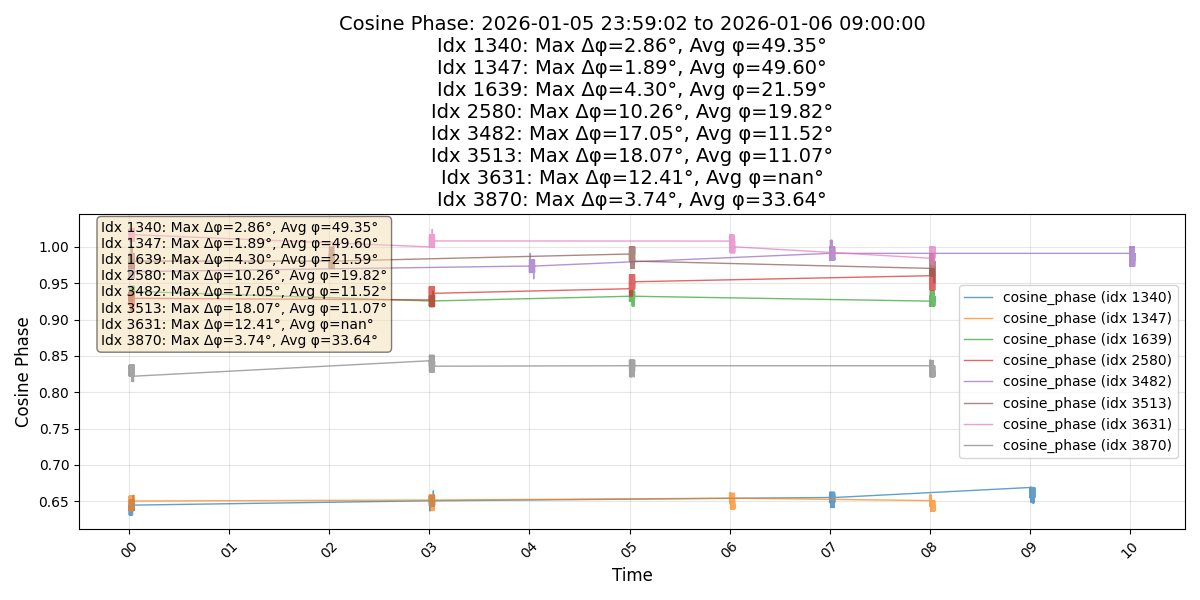


Phase shift statistics for each set:
  Set 0 (index 1340): Max phase shift: 2.86°, Average phase: 49.35°
  Set 1 (index 1347): Max phase shift: 1.89°, Average phase: 49.60°
  Set 2 (index 1639): Max phase shift: 4.30°, Average phase: 21.59°
  Set 3 (index 2580): Max phase shift: 10.26°, Average phase: 19.82°
  Set 4 (index 3482): Max phase shift: 17.05°, Average phase: 11.52°
  Set 5 (index 3513): Max phase shift: 18.07°, Average phase: 11.07°
  Set 6 (index 3631): Max phase shift: 12.41°, Average phase: nan°
  Set 7 (index 3870): Max phase shift: 3.74°, Average phase: 33.64°


In [117]:
# Plot cosine_phase for all sets on top of each other
if len(cosine_phase_all) > 0:
    from datetime import timedelta
    import matplotlib.dates as mdates
    
    base_dt_plot = datetime.datetime.strptime("00:00:00", "%H:%M:%S")
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    
    # Store statistics for each set
    max_phase_shifts = []
    average_phases = []
    
    # Plot cosine phase for each set
    for set_idx in range(len(cosine_phase_all)):
        concat_time_interferometry = concat_time_interferometry_all[set_idx]
        cosine_phase = cosine_phase_all[set_idx]
        
        concat_datetime = np.array([base_dt_plot + timedelta(seconds=float(t)) for t in concat_time_interferometry])
        
        # Calculate maximum phase shift for this set
        average_phase = 180/np.pi * np.arccos(np.mean(cosine_phase))
        max_phase_shift = 180/np.pi * np.arccos(np.min(cosine_phase)) - 180/np.pi * (np.arccos(min([1,np.max(cosine_phase)])))
        
        max_phase_shifts.append(max_phase_shift)
        average_phases.append(average_phase)
        
        label_suffix = f" (idx {data_index[set_idx]})"
        ax.plot(concat_datetime, cosine_phase, label=f'cosine_phase{label_suffix}', linewidth=1, alpha=0.7)
    
    ax.set_xlabel("Time", fontsize=12)
    ax.set_ylabel("Cosine Phase", fontsize=12)
    
    # Create title with statistics
    stats_text = "\n".join([f"Idx {data_index[i]}: Max Δφ={max_phase_shifts[i]:.2f}°, Avg φ={average_phases[i]:.2f}°" 
                            for i in range(len(max_phase_shifts))])
    ax.set_title(
        f"Cosine Phase: {start_str} to {end_str}\n{stats_text}",
        fontsize=14,
    )
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add text annotation with statistics for all sets
    stats_annotation = "\n".join([f"Idx {data_index[i]}: Max Δφ={max_phase_shifts[i]:.2f}°, Avg φ={average_phases[i]:.2f}°" 
                                  for i in range(len(max_phase_shifts))])
    ax.text(0.02, 0.98, stats_annotation, 
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Format x-axis to show time nicely
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%S'))
    ax.xaxis.set_major_locator(mdates.SecondLocator(interval=1))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.savefig(f"cosine_phase_{start_str}_{end_str}.png")
    plt.show()
    
    # Print statistics for each set
    print("\nPhase shift statistics for each set:")
    for i in range(len(max_phase_shifts)):
        print(f"  Set {i} (index {data_index[i]}): Max phase shift: {max_phase_shifts[i]:.2f}°, Average phase: {average_phases[i]:.2f}°")
else:
    print("No data loaded. Please run the data loading cell first.")


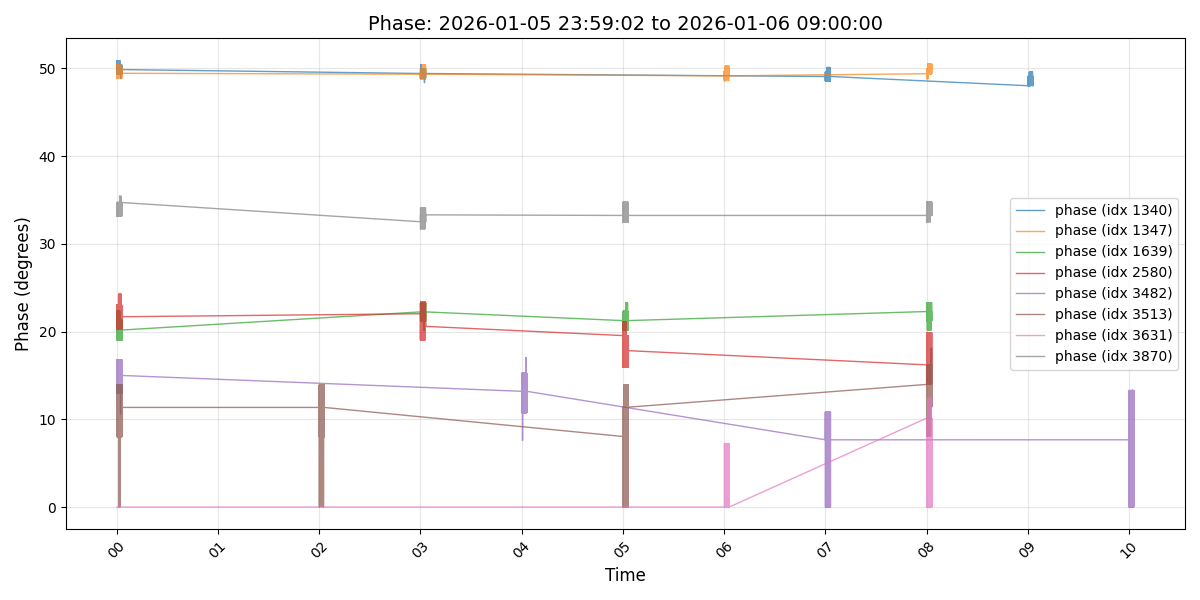

In [118]:
# Calculate and plot the phase from cosine_phase
if len(cosine_phase_all) > 0:
    from datetime import timedelta
    import matplotlib.dates as mdates
    
    base_dt_plot = datetime.datetime.strptime("00:00:00", "%H:%M:%S")
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    
    # Plot phase for each set
    for set_idx in range(len(cosine_phase_all)):
        concat_time_interferometry = concat_time_interferometry_all[set_idx]
        cosine_phase = cosine_phase_all[set_idx]
        
        # Calculate normalized_cosine and phase
        normalized_cosine = np.minimum(1, cosine_phase)
        phase = 180/np.pi * np.arccos(normalized_cosine)
        
        concat_datetime = np.array([base_dt_plot + timedelta(seconds=float(t)) for t in concat_time_interferometry])
        
        label_suffix = f" (idx {data_index[set_idx]})"
        ax.plot(concat_datetime, phase, label=f'phase{label_suffix}', linewidth=1, alpha=0.7)
    
    ax.set_xlabel("Time", fontsize=12)
    ax.set_ylabel("Phase (degrees)", fontsize=12)
    ax.set_title(
        f"Phase: {start_str} to {end_str}",
        fontsize=14,
    )
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Format x-axis to show time nicely
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%S'))
    ax.xaxis.set_major_locator(mdates.SecondLocator(interval=1))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.savefig(f"phase_{start_str}_{end_str}.png")
    plt.show()
else:
    print("No data loaded. Please run the data loading cell first.")


In [119]:
# Access cosine_phase from the first set if available
if len(cosine_phase_all) > 0:
    cosine_phase = cosine_phase_all[0]
    min([1,np.arccos(np.max(cosine_phase))])
else:
    print("No cosine phase data available.")

In [120]:
# Fourier analysis of cosine_phase_sparse for all sets
if fourier_analysis and len(cosine_phase_all) > 0:
    # Plot Fourier analysis for each set
    plt.figure(figsize=(12, 6))
    
    for set_idx in range(len(cosine_phase_all)):
        concat_time_interferometry = concat_time_interferometry_all[set_idx]
        cosine_phase = cosine_phase_all[set_idx]
        
        # Create sparse version of cosine_phase for Fourier analysis
        cosine_phase_sparse = cosine_phase[::10] 
        concat_time_interferometry_sparse = concat_time_interferometry[::10]
        
        # Subtract the mean from the data
        demeaned_cosine_phase = cosine_phase_sparse - np.mean(cosine_phase_sparse)
        
        # Apply Hamming window before FFT
        hamming_window = np.hamming(len(demeaned_cosine_phase))
        windowed_cosine_phase = demeaned_cosine_phase * hamming_window
        
        # Calculate sampling rate from time data
        # Assuming time is in seconds and measurements are evenly spaced
        if len(concat_time_interferometry_sparse) > 1:
            dt = np.mean(np.diff(concat_time_interferometry_sparse))  # Average time step in seconds
            sampling_rate = 1.0 / dt  # Sampling rate in Hz
        else:
            sampling_rate = 1.0  # Default if only one point
            dt = 1.0
        
        # Perform FFT on windowed data
        fft_values = np.fft.fft(windowed_cosine_phase)
        fft_magnitude = np.abs(fft_values)
        
        # Calculate frequency axis
        frequencies = np.fft.fftfreq(len(windowed_cosine_phase), d=dt)
        
        # Only plot positive frequencies (up to Nyquist frequency), excluding DC component
        positive_freq_idx = (frequencies > 0) & (frequencies <= sampling_rate/2)
        frequencies_positive = frequencies[positive_freq_idx]
        fft_magnitude_positive = fft_magnitude[positive_freq_idx]
        
        # Convert frequencies to periods (in seconds)
        periods_positive = 1.0 / frequencies_positive
        
        # Sort by period (ascending) for better visualization
        sort_idx = np.argsort(periods_positive)
        periods_sorted = periods_positive[sort_idx]
        fft_magnitude_sorted = fft_magnitude_positive[sort_idx]
        
        # Plot Fourier spectrum
        label_suffix = f" (idx {data_index[set_idx]})"
        periods_sorted_min = periods_sorted / 60.0
        plt.plot(periods_sorted_min, fft_magnitude_sorted, linewidth=1, label=f'Set {set_idx}{label_suffix}', alpha=0.7)
        
        # Print statistics for this set
        print(f"\nFourier Analysis Statistics for Set {set_idx} (index {data_index[set_idx]}) (cosine_phase_sparse):")
        print(f"  Original data points: {len(cosine_phase)}")
        print(f"  Sparse data points: {len(cosine_phase_sparse)} (downsampled by factor of 10)")
        print(f"  Sampling rate: {sampling_rate:.6f} Hz")
        print(f"  Nyquist frequency: {sampling_rate/2:.6f} Hz")
        print(f"  Number of points in FFT: {len(windowed_cosine_phase)}")
        print(f"  Frequency resolution: {frequencies_positive[1] - frequencies_positive[0]:.6f} Hz")
        print(f"  Max magnitude: {np.max(fft_magnitude_positive):.6f}")
        max_mag_idx = np.argmax(fft_magnitude_positive)
        print(f"  Frequency at max magnitude: {frequencies_positive[max_mag_idx]:.6f} Hz")
        print(f"  Period at max magnitude: {periods_positive[max_mag_idx]:.6f} s ({periods_positive[max_mag_idx]/60:.2f} min)")
    
    plt.xscale('log')
    plt.xlabel("Period (min)", fontsize=12)
    plt.ylabel("Magnitude (linear scale)", fontsize=12)
    plt.title(
        f"Fourier Transform of Cosine Phase (sparse): {start_str} to {end_str}",
        fontsize=14,
    )
    plt.legend()
    plt.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    plt.savefig(f"fourier_cosine_phase_{start_str}_{end_str}.png")
    plt.show()
else:
    print("No data loaded. Please run the data loading cell first.")


No data loaded. Please run the data loading cell first.


# Not Used

In [121]:
# # Calculate and plot the phase
# if 'concat_time' in locals() and 'concat_voltage' in locals() and len(concat_time) > 0:
#     # Select the data range (same as used in phase function definition)
#     start_idx = 400  # Starting from 4 hours in (assuming 1000 samples per second)
#     time_selected = concat_time[start_idx:]
#     voltage_selected = concat_voltage[start_idx:]
    
#     # Calculate phase using the phase function
#     phase_shift = phase(voltage_selected, time_selected, v_min, v_max)
    
#     # Plot the phase
#     plt.figure(figsize=(12, 6))
#     plt.plot(time_selected, phase_shift, linewidth=0.5)
#     plt.xlabel("Time (s)", fontsize=12)
#     plt.ylabel("Phase (radians)", fontsize=12)
#     plt.title("Phase Shift vs Time", fontsize=14)
#     plt.grid(True, alpha=0.3)
#     plt.tight_layout()
#     plt.show()
    
#     # # Print phase statistics
#     # print("\nPhase statistics:")
#     # print(f"  Min phase: {np.min(phase_shift):.6f} rad ({np.min(phase_shift) * 180 / np.pi:.2f}°)")
#     # print(f"  Max phase: {np.max(phase_shift):.6f} rad ({np.max(phase_shift) * 180 / np.pi:.2f}°)")
#     # print(f"  Mean phase: {np.mean(phase_shift):.6f} rad ({np.mean(phase_shift) * 180 / np.pi:.2f}°)")
#     # print(f"  Phase range: {np.max(phase_shift) - np.min(phase_shift):.6f} rad ({(np.max(phase_shift) - np.min(phase_shift)) * 180 / np.pi:.2f}°)")
#     # print(f"  Number of points: {len(phase_shift)}")
# else:
#     print("No data loaded. Please run the data loading cell first.")

In [122]:
# # Export concat_time and concat_voltage data
# if 'concat_time' in locals() and 'concat_voltage' in locals() and len(concat_time) > 0:
#     import csv
    
#     # Create filename with timestamp range
#     filename_base = f"concatenated_data_{start_str.replace(' ', '_').replace(':', '-')}_to_{end_str.replace(' ', '_').replace(':', '-')}"
    
#     # Option 1: Export to CSV (easy to open in Excel/spreadsheet programs)
#     export_filename_csv = f"{filename_base}.csv"
#     with open(export_filename_csv, 'w', newline='') as f:
#         writer = csv.writer(f)
#         writer.writerow(['time_s', 'voltage_v'])  # Header
#         # Write data in chunks to handle large files efficiently
#         chunk_size = 10000
#         for i in range(0, len(concat_time), chunk_size):
#             chunk = np.column_stack([concat_time[i:i+chunk_size], concat_voltage[i:i+chunk_size]])
#             writer.writerows(chunk)
#     print(f"Data exported to CSV: {export_filename_csv}")
#     print(f"  Rows: {len(concat_time)}")
    
#     # Option 2: Export to NPZ (numpy compressed format - preserves precision and is efficient)
#     export_filename_npz = f"{filename_base}.npz"
#     # Save base_dt as ISO format string for easy reconstruction
#     np.savez(export_filename_npz, 
#              concat_time=concat_time, 
#              concat_voltage=concat_voltage, 
#              base_dt_str=base_dt.isoformat(),
#              start_str=start_str,
#              end_str=end_str)
#     print(f"Data exported to NPZ: {export_filename_npz}")
#     print(f"  To load: data = np.load('{export_filename_npz}'); time = data['concat_time']; voltage = data['concat_voltage']")
#     print(f"  base_dt: {base_dt.isoformat()}")
# else:
#     print("No data loaded. Please run the data loading cell first.")

In [123]:
# Exporting the data


In [124]:
# v_min = 0.02489
# v_max = 0.0644

# v_min = min(v_min, np.min(concat_voltage[4*3600*1000:]))
# v_max = max(v_max, np.max(concat_voltage[4*3600*1000:]))


# def phase(v, t,v_min,v_max):
#     demeaned = v - (v_min + v_max)/2
#     swing = (v_max - v_min)/2
#     phase_shift = np.arcsin(demeaned/swing)
#     return phase_shift